In [45]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop
from scipy import stats as stats

In [ ]:
def run_simulation(n_A: int, n_B: int, n_C: int, n_rep: int = 500, los_dist: str = 'lognormal') -> dict:
    np.random.seed(42)
    n_days = 365

    sig      = np.sqrt(np.log(2))
    mu       = np.array([np.log(4*np.sqrt(2)), np.log(6*np.sqrt(2)), np.log(5*np.sqrt(2))])
    exp_mean = np.array([8.0, 12.0, 10.0])

    def arrival_a(t): return max(0.0, -(1.0/3650)*t*t + 0.1*t)
    def arrival_b(t): return arrival_a(t) / 5.0

    def sample_los(i):
        if los_dist == 'lognormal':
            return np.random.lognormal(mu[i], sig)
        else:
            return np.random.exponential(exp_mean[i])

    caps = np.array([n_A, n_B, n_C], dtype=float)

    rp_full  = np.zeros((n_rep, 3))
    rp_reloc = np.zeros((n_rep, 3))
    rp_util  = np.zeros((n_rep, 3))

    for rep in range(n_rep):
        occ_a = []; occ_b = []; occ_c = []
        rel_a = 0; rel_b = 0; rel_c = 0
        ful_a = 0; ful_b = 0; ful_c = 0
        arr_a = 0; arr_b = 0; arr_c = 0
        hist_a = []; hist_b = []; hist_c = []

        for day in range(n_days):
            occ_a = [d for d in occ_a if d > day]
            occ_b = [d for d in occ_b if d > day]
            occ_c = [d for d in occ_c if d > day]

            n_arr_a = np.random.poisson(arrival_a(day))
            n_arr_b = np.random.poisson(arrival_b(day))
            n_arr_c = np.random.poisson(6.0)

            arr_a += n_arr_a; arr_b += n_arr_b; arr_c += n_arr_c

            for _ in range(n_arr_b):
                if len(occ_b) >= n_B:
                    ful_b += 1
                if len(occ_b) < n_B:
                    occ_b.append(day + sample_los(1))
                elif len(occ_a) < n_A:
                    occ_a.append(day + sample_los(1))
                else:
                    rel_b += 1

            for _ in range(n_arr_a):
                if len(occ_a) >= n_A:
                    ful_a += 1
                if len(occ_a) < n_A:
                    occ_a.append(day + sample_los(0))
                else:
                    rel_a += 1

            for _ in range(n_arr_c):
                if len(occ_c) >= n_C:
                    ful_c += 1
                if len(occ_c) < n_C:
                    occ_c.append(day + sample_los(2))
                else:
                    rel_c += 1

            hist_a.append(len(occ_a))
            hist_b.append(len(occ_b))
            hist_c.append(len(occ_c))

        rp_full[rep]  = [ful_a / max(arr_a, 1), ful_b / max(arr_b, 1), ful_c / max(arr_c, 1)]
        rp_reloc[rep] = [rel_a, rel_b, rel_c]
        rp_util[rep]  = [np.mean(hist_a) / n_A if n_A > 0 else 0.0,
                         np.mean(hist_b) / n_B if n_B > 0 else 0.0,
                         np.mean(hist_c) / n_C if n_C > 0 else 0.0]

    def ci95(arr2d):
        m  = arr2d.mean(axis=0)
        hc = 1.96 * arr2d.std(axis=0) / np.sqrt(n_rep)
        return m, hc

    tot = rp_reloc.sum(axis=1)
    return dict(
        p_full      = ci95(rp_full),
        reloc       = ci95(rp_reloc),
        util        = ci95(rp_util),
        total_reloc = (tot.mean(), 1.96 * tot.std() / np.sqrt(n_rep)),
    )


In [47]:
def f(val, ci, pct=False):
    s = 100 if pct else 1
    u = '%' if pct else ''
    return f"{val*s:7.2f} +- {ci*s:.2f}{u}"


def print_results(r: dict, nA: int, nB: int, nC: int, title: str = ""):
    pm, pci = r['p_full']
    rm, rci = r['reloc']
    um, uci = r['util']
    tm, tci = r['total_reloc']

    if title:
        print(f"{title}")
    print(f"Beds:  A={nA},  B={nB},  C={nC}   (total = {nA+nB+nC})\n")
    print(f"P(primary ward full on arrival):")
    print(f"    Ward A : {f(pm[0], pci[0], True)}")
    print(f"    Ward B : {f(pm[1], pci[1], True)}")
    print(f"    Ward C : {f(pm[2], pci[2], True)}")
    print(f"Mean relocations per year:")
    print(f"    Ward A : {f(rm[0], rci[0])}")
    print(f"    Ward B : {f(rm[1], rci[1])}")
    print(f"    Ward C : {f(rm[2], rci[2])}")
    print(f"    Total  : {f(tm,    tci)}")
    print(f"Mean bed utilisation:")
    print(f"    Ward A : {f(um[0], uci[0], True)}")
    print(f"    Ward B : {f(um[1], uci[1], True)}")
    print(f"    Ward C : {f(um[2], uci[2], True)}")


In [ ]:
TOTAL     = 75
N_PRIMARY = 1000
N_SWEEP   = 500
N_SENS    = 1000
N_BEDS    = 500

nA0, nB0, nC0 = 20, 5, 50

print(f"Primary analysis  ({N_PRIMARY} reps, lognormal LOS)\n")
r_prim = run_simulation(nA0, nB0, nC0, n_rep=N_PRIMARY, los_dist='lognormal')
print_results(r_prim, nA0, nB0, nC0, "Primary Analysis, Lognormal LOS")


In [49]:
print(f"Bed-distribution sweep ({N_SWEEP} reps per config)")

nB_range = range(1, 16)
nC_range = range(1, TOTAL)
sweep    = {}

for nB in nB_range:
    for nC in nC_range:
        nA = TOTAL - nB - nC
        if nA < 1:
            continue
        r = run_simulation(nA, nB, nC, n_rep=N_SWEEP)
        sweep[(nA, nB, nC)] = r['total_reloc'][0]

opt_key  = min(sweep, key=sweep.get)
nA_opt, nB_opt, nC_opt = opt_key
print(f"\nOptimal (sweep): A={nA_opt}, B={nB_opt}, C={nC_opt}" f" - total reloc aprox {sweep[opt_key]:.1f}")

r_opt = run_simulation(nA_opt, nB_opt, nC_opt, n_rep=N_PRIMARY)
print_results(r_opt, nA_opt, nB_opt, nC_opt, "Optimal Bed Distribution")


Bed-distribution sweep (100 reps per config)

Optimal (sweep): A=35, B=1, C=39 - total reloc aprox 2291.9
Optimal Bed Distribution
Beds:  A=35,  B=1,  C=39   (total = 75)

P(primary ward full on arrival):
    Ward A :   63.88 +- 0.11%
    Ward B :   93.79 +- 0.07%
    Ward C :   38.00 +- 0.12%
Mean relocations per year:
    Ward A : 1419.39 +- 3.48
    Ward B :   46.47 +- 0.62
    Ward C :  831.63 +- 3.32
    Total  : 2297.49 +- 4.93
Mean bed utilisation:
    Ward A :   88.87 +- 0.06%
    Ward B :   92.37 +- 0.14%
    Ward C :   97.54 +- 0.02%


In [50]:
print(f"LOS sensitivity ({N_SENS} reps, same beds as primary)\n")
r_exp = run_simulation(nA0, nB0, nC0, n_rep=N_SENS, los_dist='exponential')
print_results(r_exp, nA0, nB0, nC0, "Exponential LOS (same bed distribution as primary)")

LOS sensitivity (1000 reps, same beds as primary)

Exponential LOS (same bed distribution as primary)
Beds:  A=20,  B=5,  C=50   (total = 75)

P(primary ward full on arrival):
    Ward A :   78.47 +- 0.08%
    Ward B :   70.80 +- 0.16%
    Ward C :   22.45 +- 0.12%
Mean relocations per year:
    Ward A : 1741.45 +- 3.35
    Ward B :   97.10 +- 0.91
    Ward C :  491.94 +- 3.18
    Total  : 2330.49 +- 4.78
Mean bed utilisation:
    Ward A :   92.20 +- 0.06%
    Ward B :   87.60 +- 0.13%
    Ward C :   95.28 +- 0.04%


In [51]:
r_opt_exp = run_simulation(nA_opt, nB_opt, nC_opt, n_rep=N_SENS, los_dist='exponential')
print_results(r_opt_exp, nA_opt, nB_opt, nC_opt,"Exponential LOS  (optimal bed distribution)")

Exponential LOS  (optimal bed distribution)
Beds:  A=35,  B=1,  C=39   (total = 75)

P(primary ward full on arrival):
    Ward A :   63.97 +- 0.11%
    Ward B :   93.77 +- 0.07%
    Ward C :   38.02 +- 0.12%
Mean relocations per year:
    Ward A : 1422.12 +- 3.66
    Ward B :   47.09 +- 0.61
    Ward C :  831.88 +- 3.51
    Total  : 2301.09 +- 5.03
Mean bed utilisation:
    Ward A :   88.87 +- 0.06%
    Ward B :   92.43 +- 0.13%
    Ward C :   97.44 +- 0.02%


In [52]:
print(f"Total-bed sensitivity  ({N_BEDS} reps each)")
bed_totals = [50, 60, 65, 70, 75, 80, 90, 100]
beds_res   = []

for tot in bed_totals:
    nA = max(1, round(nA0 / TOTAL * tot))
    nB = max(1, round(nB0 / TOTAL * tot))
    nC = max(1, tot - nA - nB)
    r  = run_simulation(nA, nB, nC, n_rep=N_BEDS)
    tm, tci = r['total_reloc']
    beds_res.append((tot, nA, nB, nC, tm, tci,
                    r['util'][0].copy(), r['util'][1].copy()))
    print(f"    beds={tot:3d}  (A={nA:2d}, B={nB:2d}, C={nC:2d}):  "
        f"reloc = {tm:6.1f} +- {tci:.1f}")


Total-bed sensitivity  (500 reps each)
    beds= 50  (A=13, B= 3, C=34):  reloc = 3137.6 +- 7.0
    beds= 60  (A=16, B= 4, C=40):  reloc = 2804.7 +- 6.9
    beds= 65  (A=17, B= 4, C=44):  reloc = 2639.3 +- 6.6
    beds= 70  (A=19, B= 5, C=46):  reloc = 2476.4 +- 6.9
    beds= 75  (A=20, B= 5, C=50):  reloc = 2322.8 +- 6.9
    beds= 80  (A=21, B= 5, C=54):  reloc = 2177.9 +- 6.8
    beds= 90  (A=24, B= 6, C=60):  reloc = 1896.0 +- 6.6
    beds=100  (A=27, B= 7, C=66):  reloc = 1657.8 +- 6.0


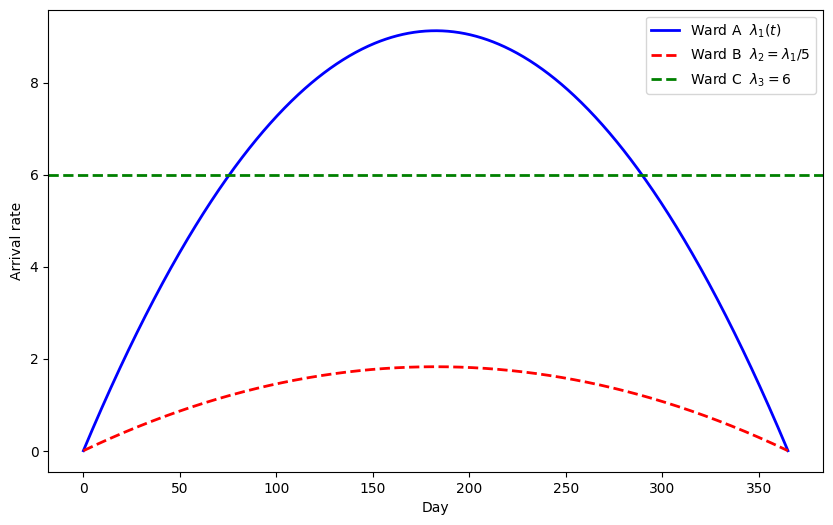

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))

tv  = np.linspace(0, 365, 1000)
l1v = np.maximum(0, -(1/3650)*tv**2 + 0.1*tv)

ax.plot(tv, l1v,   'b-',  lw=2, label=r'Ward A  $\lambda_1(t)$')
ax.plot(tv, l1v/5, 'r--', lw=2, label=r'Ward B  $\lambda_2 = \lambda_1/5$')
ax.axhline(6, color='g', ls='--', lw=2, label=r'Ward C  $\lambda_3 = 6$')
ax.set(xlabel='Day', ylabel='Arrival rate')
ax.legend()

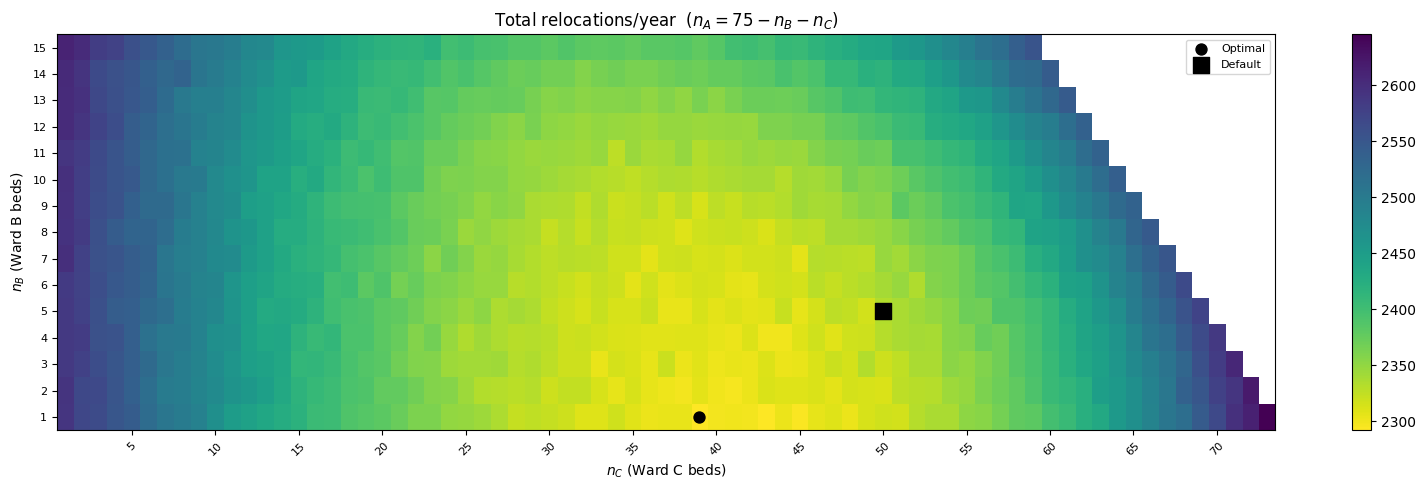

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

nBv = sorted(set(k[1] for k in sweep))
nCv = sorted(set(k[2] for k in sweep))
Z   = np.full((len(nBv), len(nCv)), np.nan)
for i, nb in enumerate(nBv):
    for j, nc in enumerate(nCv):
        na = TOTAL - nb - nc
        if na >= 1 and (na, nb, nc) in sweep:
            Z[i, j] = sweep[(na, nb, nc)]

im = ax.imshow(Z, aspect='auto', origin='lower', cmap='viridis_r')

tick_step = 5
tick_indices = [j for j, nc in enumerate(nCv) if nc % tick_step == 0]
ax.set_xticks(tick_indices)
ax.set_xticklabels([nCv[j] for j in tick_indices], rotation=45, fontsize=8)
ax.set_yticks(range(len(nBv)))
ax.set_yticklabels(nBv, fontsize=8)

ax.set(xlabel='$n_C$ (Ward C beds)', ylabel='$n_B$ (Ward B beds)',
       title=f'Total relocations/year  ($n_A = {TOTAL}-n_B-n_C$)')
ax.scatter([nCv.index(nC_opt)], [nBv.index(nB_opt)], marker='.', s=250, c='black', zorder=6, label='Optimal')
ax.scatter([nCv.index(nC0)],    [nBv.index(nB0)],    marker='s', s=120, c='black', zorder=6, label='Default')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


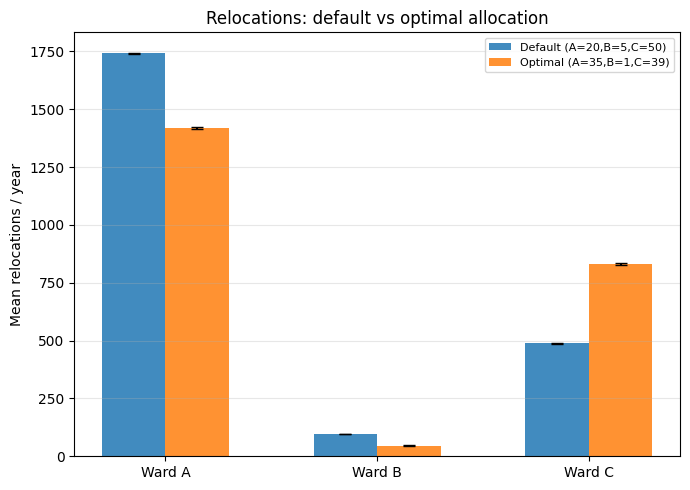

In [55]:
fig, ax = plt.subplots(figsize=(7, 5))

cats  = ['Ward A', 'Ward B', 'Ward C']
x     = np.arange(3);  w = 0.30
rm_p, rci_p = r_prim['reloc']
rm_o, rci_o = r_opt['reloc']
ax.bar(x-w/2, rm_p, w, yerr=rci_p, capsize=4, alpha=0.85, label=f'Default (A={nA0},B={nB0},C={nC0})')
ax.bar(x+w/2, rm_o, w, yerr=rci_o, capsize=4, alpha=0.85, label=f'Optimal (A={nA_opt},B={nB_opt},C={nC_opt})')
ax.set(xticks=x, xticklabels=cats, ylabel='Mean relocations / year', title='Relocations: default vs optimal allocation')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

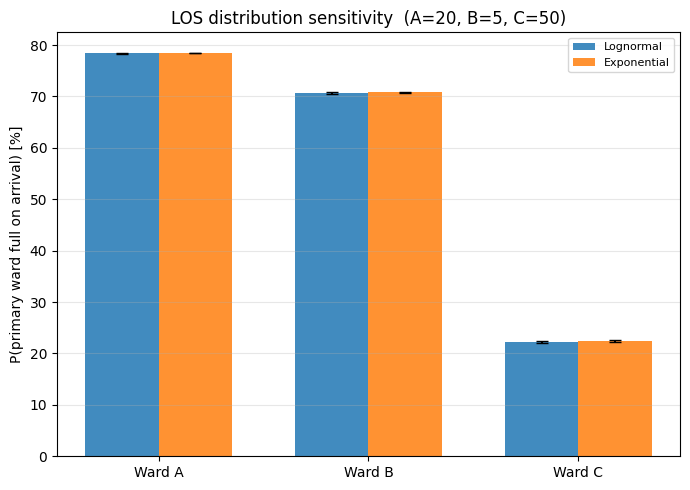

In [56]:
fig, ax = plt.subplots(figsize=(7, 5))

cats = ['Ward A', 'Ward B', 'Ward C']
pm_l, pci_l = r_prim['p_full']
pm_e, pci_e = r_exp['p_full']
x = np.arange(3);  w = 0.35
ax.bar(x-w/2, pm_l*100, w, yerr=pci_l*100, capsize=4, alpha=0.85, label='Lognormal')
ax.bar(x+w/2, pm_e*100, w, yerr=pci_e*100, capsize=4, alpha=0.85, label='Exponential')
ax.set(xticks=x, xticklabels=cats, ylabel='P(primary ward full on arrival) [%]', title=f'LOS distribution sensitivity  (A={nA0}, B={nB0}, C={nC0})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


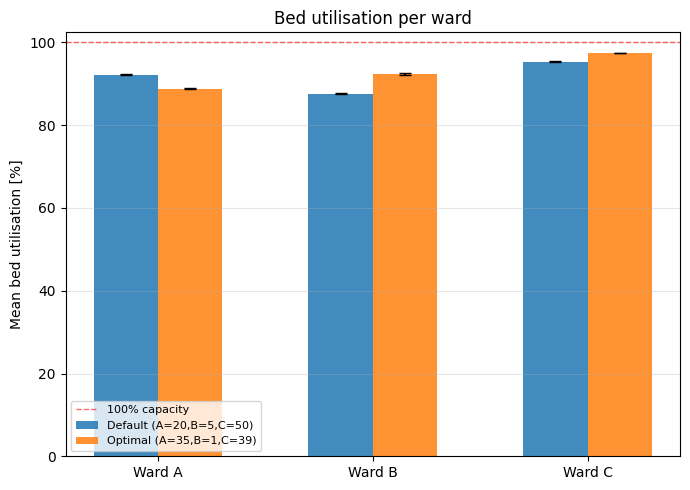

In [57]:
fig, ax = plt.subplots(figsize=(7, 5))

wards = ['Ward A', 'Ward B', 'Ward C']
x     = np.arange(3);  w = 0.30
um_p, uci_p = r_prim['util']
um_o, uci_o = r_opt['util']
ax.bar(x-w/2, um_p*100, w, yerr=uci_p*100, capsize=4, alpha=0.85, label=f'Default (A={nA0},B={nB0},C={nC0})')
ax.bar(x+w/2, um_o*100, w, yerr=uci_o*100, capsize=4, alpha=0.85, label=f'Optimal (A={nA_opt},B={nB_opt},C={nC_opt})')
ax.axhline(100, color='red', ls='--', lw=1, alpha=0.6, label='100% capacity')
ax.set(xticks=x, xticklabels=wards, ylabel='Mean bed utilisation [%]', title='Bed utilisation per ward')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

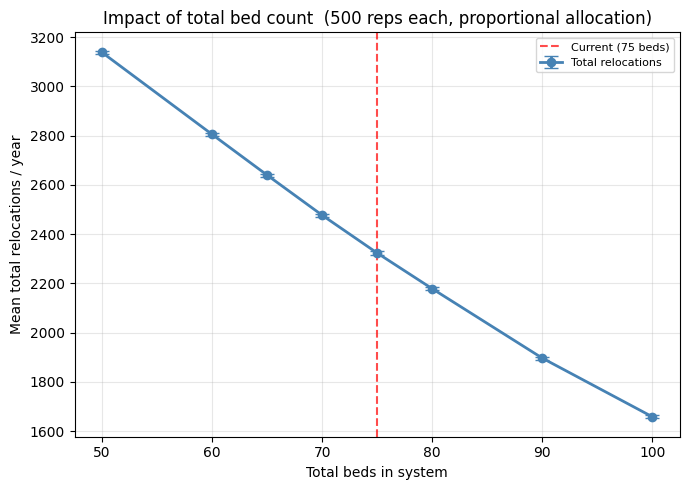

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))

tots   = [b[0] for b in beds_res]
relocs = [b[4] for b in beds_res]
cis    = [b[5] for b in beds_res]
ax.errorbar(tots, relocs, yerr=cis, marker='o', lw=2, capsize=5, color='steelblue', label='Total relocations')
ax.axvline(75, color='red', ls='--', alpha=0.7, label='Current (75 beds)')
ax.set(xlabel='Total beds in system', ylabel='Mean total relocations / year', title=f'Impact of total bed count  ({N_BEDS} reps each, proportional allocation)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def raw_reloc(n_A, n_B, n_C, n_rep=1000, los_dist='lognormal'):
    np.random.seed(42)
    n_days = 365
    sig      = np.sqrt(np.log(2))
    mu       = np.array([np.log(4*np.sqrt(2)), np.log(6*np.sqrt(2)), np.log(5*np.sqrt(2))])
    exp_mean = np.array([8., 12., 10.])

    def arrival_a(t): return max(0., -(1/3650)*t*t + 0.1*t)
    def arrival_b(t): return arrival_a(t) / 5.0

    def sample_los(i):
        if los_dist == 'lognormal':
            return np.random.lognormal(mu[i], sig)
        else:
            return np.random.exponential(exp_mean[i])

    totals = np.zeros(n_rep)
    for rep in range(n_rep):
        occ_a = []; occ_b = []; occ_c = []
        rel_a = 0; rel_b = 0; rel_c = 0

        for day in range(n_days):
            occ_a = [d for d in occ_a if d > day]
            occ_b = [d for d in occ_b if d > day]
            occ_c = [d for d in occ_c if d > day]

            n_arr_a = np.random.poisson(arrival_a(day))
            n_arr_b = np.random.poisson(arrival_b(day))
            n_arr_c = np.random.poisson(6.0)

            for _ in range(n_arr_b):
                if len(occ_b) < n_B:
                    occ_b.append(day + sample_los(1))
                elif len(occ_a) < n_A:
                    occ_a.append(day + sample_los(1))
                else:
                    rel_b += 1

            for _ in range(n_arr_a):
                if len(occ_a) < n_A:
                    occ_a.append(day + sample_los(0))
                else:
                    rel_a += 1

            for _ in range(n_arr_c):
                if len(occ_c) < n_C:
                    occ_c.append(day + sample_los(2))
                else:
                    rel_c += 1

        totals[rep] = rel_a + rel_b + rel_c
    return totals

In [71]:
beds_default = (nA0, nB0, nC0)
beds_opt_ln  = (nA_opt, nB_opt, nC_opt)
beds_opt_exp = (35, 3, 37)

raw_default_ln  = raw_reloc(*beds_default, n_rep=1000, los_dist='lognormal')
raw_optimal_ln  = raw_reloc(*beds_opt_ln,  n_rep=1000, los_dist='lognormal')
raw_default_exp = raw_reloc(*beds_default, n_rep=1000, los_dist='exponential')
raw_optimal_exp = raw_reloc(*beds_opt_exp, n_rep=1000, los_dist='exponential')

raw_def = raw_default_ln
raw_opt = raw_optimal_ln

print(f"  Default : {raw_default_ln.mean():.1f} ± {raw_default_ln.std():.1f}")
print(f"  Optimal : {raw_optimal_ln.mean():.1f} ± {raw_optimal_ln.std():.1f}")

  Default : 2325.7 ± 76.3
  Optimal : 2297.5 ± 79.5


In [72]:
raw_ln  = raw_reloc(20, 5, 50, n_rep=1000, los_dist='lognormal')
raw_exp = raw_reloc(20, 5, 50, n_rep=1000, los_dist='exponential')

print(f"  Lognormal   : {raw_ln.mean():.1f} ± {raw_ln.std():.1f}")
print(f"  Exponential : {raw_exp.mean():.1f} ± {raw_exp.std():.1f}")


  Lognormal   : 2325.7 ± 76.3
  Exponential : 2330.5 ± 77.1



Lognormal LOS, Default (20, 5, 50) vs Optimal (35, 1, 39):
  mean: 2325.7 vs 2297.5
  KS = 0.1450,  p = 1.39e-09

Exponential LOS, Default (20, 5, 50) vs Optimal (35, 1, 39):
  mean: 2330.5 vs 2301.1
  KS = 0.1470,  p = 7.71e-10

Default beds (20, 5, 50), Lognormal vs Exponential:
  mean: 2325.7 vs 2330.5
  KS = 0.0350,  p = 5.73e-01


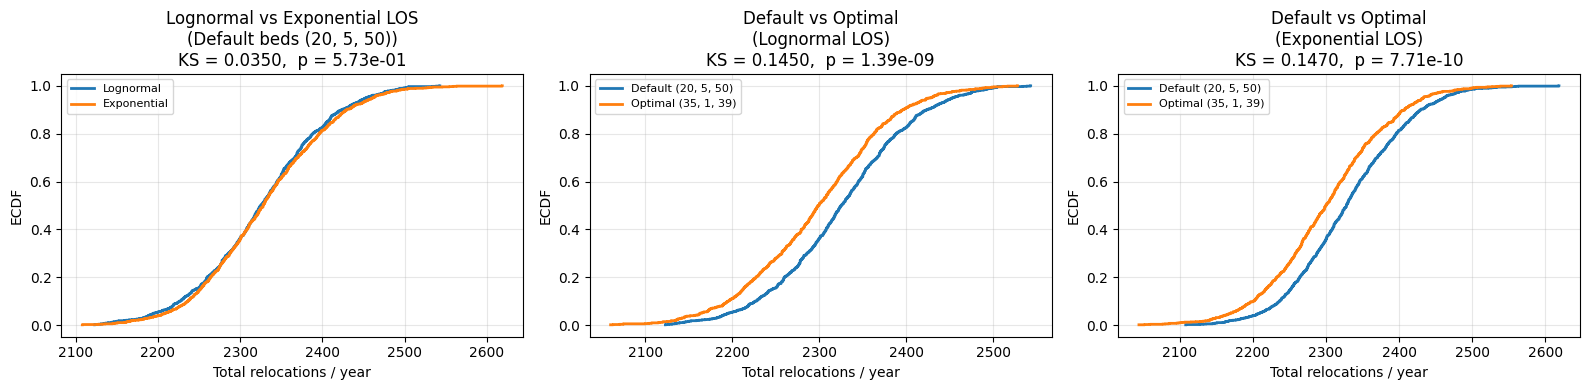

In [64]:
comparisons = [
    (raw_default_ln,  raw_optimal_ln,  f'Default {beds_default}',  f'Optimal {beds_opt_ln}',  'Lognormal LOS'),
    (raw_default_exp, raw_optimal_exp, f'Default {beds_default}',  f'Optimal {beds_opt_exp}', 'Exponential LOS'),
    (raw_default_ln,  raw_default_exp, 'Lognormal',                'Exponential',             f'Default beds {beds_default}'),
]
for a, b, la, lb, label in comparisons:
    ks, p = stats.ks_2samp(a, b)
    print(f"\n{label}, {la} vs {lb}:")
    print(f"  mean: {a.mean():.1f} vs {b.mean():.1f}")
    print(f"  KS = {ks:.4f},  p = {p:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_data = [
    (raw_default_ln,  raw_default_exp, 'Lognormal',               'Exponential',             f'Lognormal vs Exponential LOS\n(Default beds {beds_default})'),
    (raw_default_ln,  raw_optimal_ln,  f'Default {beds_default}', f'Optimal {beds_opt_ln}',  'Default vs Optimal\n(Lognormal LOS)'),
    (raw_default_exp, raw_optimal_exp, f'Default {beds_default}', f'Optimal {beds_opt_exp}', 'Default vs Optimal\n(Exponential LOS)'),
]
for ax, (a, b, la, lb, title) in zip(axes, plot_data):
    for sample, label in [(a, la), (b, lb)]:
        x = np.sort(sample)
        y = np.arange(1, len(x)+1) / len(x)
        ax.step(x, y, where='post', label=label, lw=2)
    ks, p = stats.ks_2samp(a, b)
    ax.set(xlabel='Total relocations / year', ylabel='ECDF',
           title=f'{title}\nKS = {ks:.4f},  p = {p:.2e}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
